In [62]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from ddpg_td3_layernorm_lunar.ddpg import DDPG
from ddpg_td3_layernorm_lunar.replay_buffer import ReplayBuffer
from ddpg_td3_layernorm_lunar.run import run_policy
from ddpg_td3_layernorm_lunar.td3 import TD3

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Most of the following code is based on https://github.com/sfujim/td3

In [63]:
algo = DDPG
seed = 1
layer_normalization = True

In [64]:
res = run_policy(DDPG, "LunarLander-v3", seed=1)

  0%|          | 0/500000 [00:00<?, ?it/s]

KeyboardInterrupt: 

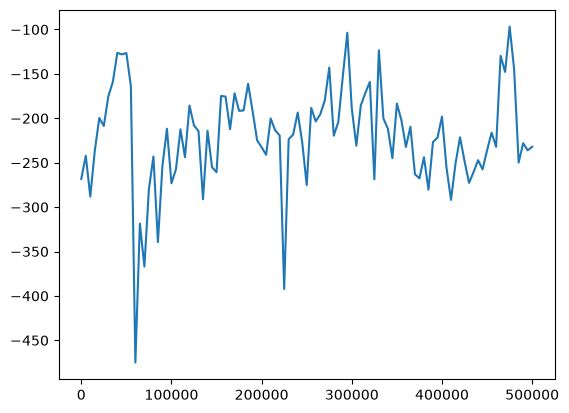

In [55]:
data = np.load("../results/DDPG_seed_0_ln_False.npz")
steps = data["steps"]
evaluations = data["evaluations"]
biases = data["biases"]

plt.plot(steps, evaluations)

In [33]:
def load_and_process_data(
    results_dir: Path,
    algo: type[DDPG] | type[TD3],
    layer_normalization: bool,
    seeds: range | list,
):
    seeds = list(seeds)

    steps = []
    evaluations = []
    biases = []

    for seed in seeds:
        path = results_dir / (
            f"{algo.__name__}_seed_{seed}_ln_{layer_normalization}.npz"
        )

        with np.load(path) as data:
            steps.append(data["steps"])
            evaluations.append(data["evaluations"])
            biases.append(data["biases"])

    steps = np.stack(steps)
    evaluations = np.stack(evaluations)
    biases = np.stack(biases)

    # Make sure all runs use the same evaluation steps
    if not np.all(steps == steps[0]):
        raise ValueError("Evaluation steps differ between runs.")

    # Number of runs to remove from EACH side
    n_trim = int(len(seeds) * 0.1)

    def trimmed_stats(x):
        x = np.sort(x, axis=0)

        if n_trim > 0:
            x = x[n_trim:-n_trim]

        return x.mean(axis=0), x.std(axis=0)

    mean_evaluations, std_evaluations = trimmed_stats(evaluations)
    mean_biases, std_biases = trimmed_stats(biases)

    return (
        steps[0],
        mean_evaluations,
        std_evaluations,
        mean_biases,
        std_biases,
    )


results_dir = Path("../results")

steps, mean_evaluations, std_evaluations, mean_biases, std_biases = (
    load_and_process_data(
        results_dir,
        DDPG,
        True,
        [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 12, 13, 14],
    )
)

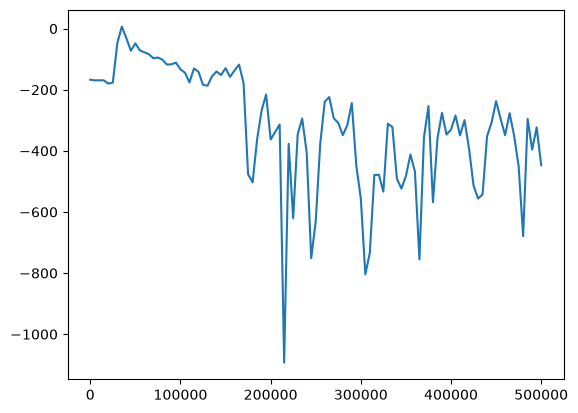

In [34]:
plt.plot(steps, mean_evaluations)

In [ ]:
import numpy as np


def trimmed_stats(runs, trim=0.1):
    n_runs = runs.shape[0]
    n_trim = int(n_runs * trim)

    # Sort runs independently at each timestep
    sorted_runs = np.sort(runs, axis=0)

    # Remove bottom and top 10%
    if n_trim > 0:
        trimmed = sorted_runs[n_trim:-n_trim]
    else:
        trimmed = sorted_runs

    mean = trimmed.mean(axis=0)
    std = trimmed.std(axis=0)

    return mean, std

In [ ]:
# algo = DDPG
# seed = 1
# layer_normalization = True

res = {}
for algo in [DDPG, TD3]:
    for layer_normalization in [False, True]:
        steps = []
        evaluations = []
        biases = []
        for seed in range(15):
            data = np.load(
                f"../results/{algo.__name__}_seed_{seed}_ln_{layer_normalization}.npz"
            )
            steps.append(data["steps"])
            evaluations.append(data["evaluations"])
            biases.append(data["biases"])
        res[f"{algo.__name__}_ln_{layer_normalization}"] = (steps, evaluations, biases)

FileNotFoundError: [Errno 2] No such file or directory: '../results/DDPG_seed_4_ln_True.npz'

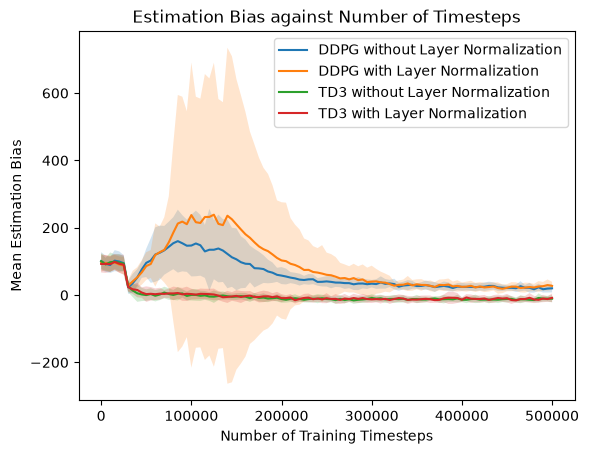

In [ ]:
plt.title("Estimation Bias against Number of Timesteps")
for algo in [DDPG, TD3]:
    for layer_normalization in [False, True]:
        data = np.stack(res[f"{algo.__name__}_ln_{layer_normalization}"][0]).mean(0)
        y = np.stack(res[f"{algo.__name__}_ln_{layer_normalization}"][2]).mean(0)
        y_std = np.stack(res[f"{algo.__name__}_ln_{layer_normalization}"][2]).std(0)
        plt.plot(
            data,
            y,
            label=f"{algo.__name__} {'with' if layer_normalization else 'without'} Layer Normalization",
        )
        plt.fill_between(data, y - y_std, y + y_std, alpha=0.2)
plt.xlabel("Number of Training Timesteps")
plt.ylabel("Mean Estimation Bias")
plt.legend()
plt.show()

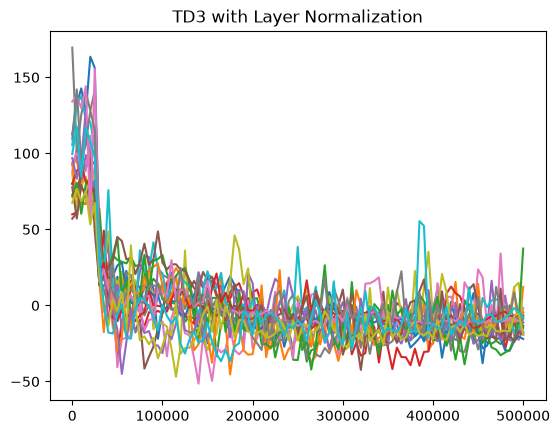

In [ ]:
plt.title(
    f"{algo.__name__} {'with' if layer_normalization else 'without'} Layer Normalization"
)
for seed in range(20):
    data = np.load(
        f"../results/{algo.__name__}_seed_{seed}_ln_{layer_normalization}.npz"
    )
    steps = data["steps"]
    evaluations = data["evaluations"]
    biases = data["biases"]

    plt.plot(steps, biases)
plt.show()

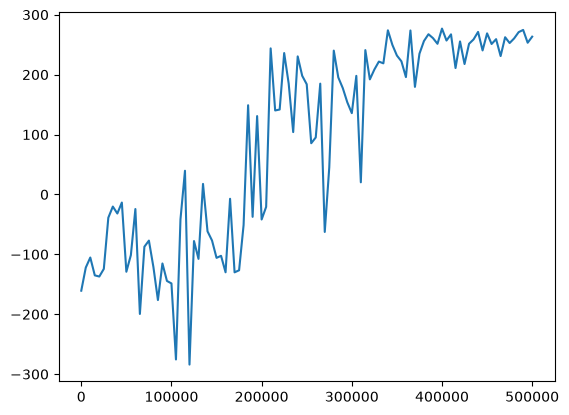

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")